# Data analysis for generated independent instances

This notebook labels 1000 independently generated instances using the DP solver, then inspects how often ratio-greedy fials and how severe those failures are.

Each row represents one knapsack instance and retains its generation seed and family. `failure` is true exactly when the greedy value is below the optimal DP value. `relative_gap` measures the fraction of optimal value lost by greedy; it is zero when greedy is optimal.

In [1]:
from pathlib import Path

from IPython.display import Image, display

from knapsack_ml_experiment import (
    build_labeled_dataset,
    generate_independent_instances,
    save_failure_plots,
)

In [2]:
instances = generate_independent_instances()
dataset = build_labeled_dataset(instances)
dataset.head()

,seed,family,number_of_items,capacity,weights,values,greedy_value,optimal_value,failure,relative_gap
0,0,independent,20,206,"(25, 27, 17, 32, 20, 23, 14, 9, 9, 7, 17, 46, ...","(98, 6, 66, 52, 62, 75, 65, 37, 97, 80, 69, 78...",1011,1011,False,0.0
1,1,independent,20,250,"(9, 49, 17, 32, 29, 42, 14, 32, 25, 39, 50, 45...","(73, 9, 16, 98, 61, 49, 13, 4, 56, 98, 1, 58, ...",855,855,False,0.0
2,2,independent,20,206,"(4, 6, 11, 43, 17, 14, 3, 44, 28, 26, 33, 35, ...","(12, 47, 95, 40, 78, 78, 75, 21, 82, 93, 48, 5...",840,840,False,0.0
3,3,independent,20,294,"(16, 35, 24, 31, 38, 39, 31, 36, 13, 31, 36, 2...","(76, 17, 78, 81, 9, 2, 34, 30, 92, 70, 61, 82,...",806,806,False,0.0
4,4,independent,20,204,"(16, 7, 26, 10, 5, 26, 19, 4, 34, 24, 50, 7, 1...","(39, 93, 62, 12, 3, 71, 98, 29, 69, 36, 23, 34...",783,783,False,0.0


### Save the recorded results

The CSV contains the generated inputs plus `greedy_value`, `optimal_value`, `failure`, and `relative_gap`. Keeping the seed makes every row reproducible.

In [5]:
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

output_directory = project_root / "artifacts"
output_directory.mkdir(parents=True, exist_ok=True)
dataset.to_csv(output_directory / "independent_instances.csv", index=False)
save_failure_plots(dataset, output_directory)

### Failure frequency

This plot answers the first descriptive question: on this particular independent family, how often is ratio-greedy optimal and how often does it fail? However, this is dataset observation and there is no evidence that the same frequency will hold for other families.

Greedy failures: 466 / 1000 (46.6%)


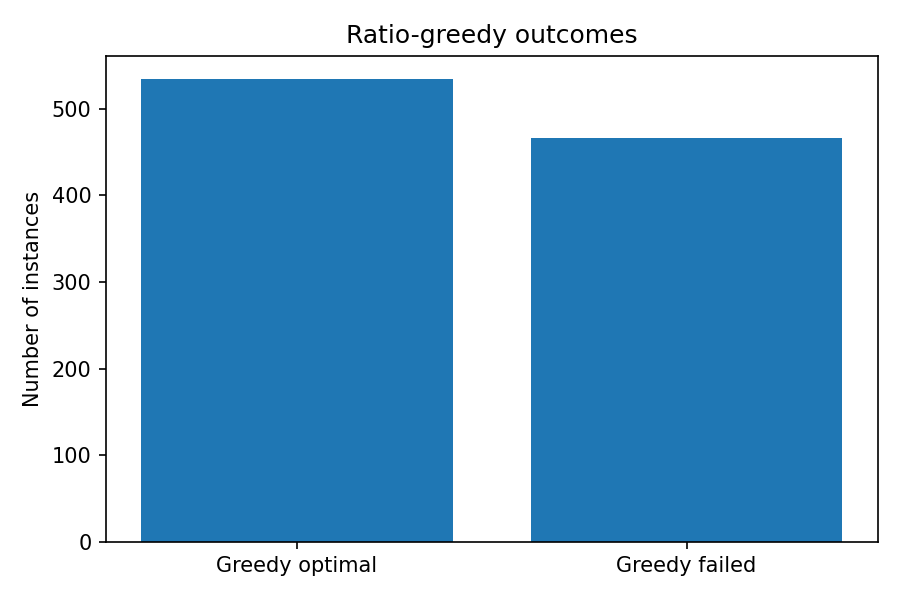

In [8]:
failure_count = int(dataset["failure"].sum())
failure_rate = dataset["failure"].mean()
print(f"Greedy failures: {failure_count} / {len(dataset)} ({failure_rate:.1%})")
display(Image(filename=output_directory / "failure_frequency.png"))

### Relative-gap distribution

The histogram includes only failed instances. Otherwise, the many zero gaps from successful greedy solutions would dominate the plot and obscure the severity of actual failures.

Mean failed-instance gap: 1.48%
Maximum gap: 6.28%


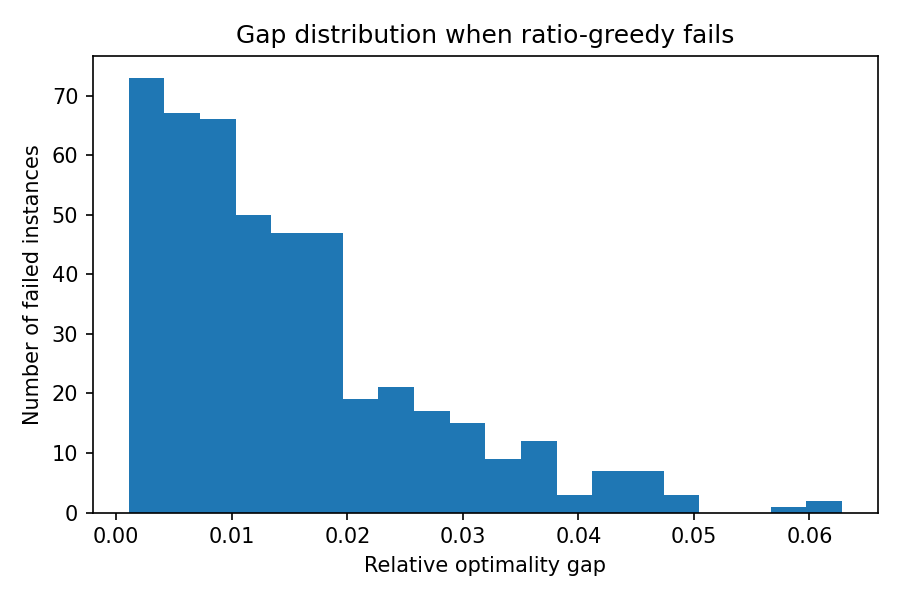

In [9]:
failed_gaps = dataset.loc[dataset["failure"], "relative_gap"]
print(f"Mean failed-instance gap: {failed_gaps.mean():.2%}")
print(f"Maximum gap: {failed_gaps.max():.2%}")
display(Image(filename=output_directory / "relative_gap_distribution.png"))

### Interpretation checkpoint

These plots describe only the current setup: 20 items, weights from 1–50, values from 1–100, and capacity equal to half the total weight. Before training ML, the important checks are whether failures exist in useful numbers and whether their gaps are practically meaningful. Different instance families may produce very different behavior.